# Exercise scraping books.toscrape.com

You are going to extract data from http://books.toscrape.com. This site is built for scraping. 

Goal is to download the 20 book titles and their sales prices on the site's first page: 

First install the necessary libraries. When you already have those libs installed, don't run this cell. 

In [1]:
# Only run if not already installed!

! pip install requests
! pip install BeautifulSoup4

You should consider upgrading via the 'C:\Users\USER\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'C:\Users\USER\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


Import the packages requests and BeautifulSoup  


In [3]:
import requests 
from bs4 import BeautifulSoup



In the next cell request the page 'http://books.toscrape.com/index.html' and show the first and last 100 characters. After running this cell, you have the entire page locally. 

In [4]:
url = 'http://books.toscrape.com/index.html'
response = requests.get(url)
print(response.text[:100])
print(response.text[-100])
soup = BeautifulSoup(response.text, 'html.parser')



<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![end
 


**Step 1**

Create a list that contains the 20 book titles on the first page and print it. 

![](images/scraping_image_part1.PNG)


In [5]:

titles = [pod.h3.a['title'] 
          for pod in soup.select('article.product_pod')]
print(titles)



['A Light in the Attic', 'Tipping the Velvet', 'Soumission', 'Sharp Objects', 'Sapiens: A Brief History of Humankind', 'The Requiem Red', 'The Dirty Little Secrets of Getting Your Dream Job', 'The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull', 'The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics', 'The Black Maria', 'Starving Hearts (Triangular Trade Trilogy, #1)', "Shakespeare's Sonnets", 'Set Me Free', "Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)", 'Rip it Up and Start Again', 'Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991', 'Olio', 'Mesaerion: The Best Science Fiction Stories 1800-1849', 'Libertarianism for Beginners', "It's Only the Himalayas"]


**Step 2**

Next, create a list of the book prices. 
For the first books, it looks like this:

![](images/scraping_image_part2.PNG)

In [7]:
prices = [pod.select_one('p.price_color').text
          for pod in soup.select('article.product_pod')]
print(prices)



['Â£51.77', 'Â£53.74', 'Â£50.10', 'Â£47.82', 'Â£54.23', 'Â£22.65', 'Â£33.34', 'Â£17.93', 'Â£22.60', 'Â£52.15', 'Â£13.99', 'Â£20.66', 'Â£17.46', 'Â£52.29', 'Â£35.02', 'Â£57.25', 'Â£23.88', 'Â£37.59', 'Â£51.33', 'Â£45.17']


**Step 3**

Loop over the 2 lists with book titles and prices using a built-in function.  
The result looks like this:  

![](images/scraping_image_part3.PNG)

In [8]:
for title, price in zip(titles, prices):
    print(f"{title} : {price}")# Up to you!



A Light in the Attic : Â£51.77
Tipping the Velvet : Â£53.74
Soumission : Â£50.10
Sharp Objects : Â£47.82
Sapiens: A Brief History of Humankind : Â£54.23
The Requiem Red : Â£22.65
The Dirty Little Secrets of Getting Your Dream Job : Â£33.34
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull : Â£17.93
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics : Â£22.60
The Black Maria : Â£52.15
Starving Hearts (Triangular Trade Trilogy, #1) : Â£13.99
Shakespeare's Sonnets : Â£20.66
Set Me Free : Â£17.46
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1) : Â£52.29
Rip it Up and Start Again : Â£35.02
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991 : Â£57.25
Olio : Â£23.88
Mesaerion: The Best Science Fiction Stories 1800-1849 : Â£37.59
Libertarianism for Beginners : Â£51.33
It's Only the Himalayas : Â£45.17


**Step 4**  
Create an overview of all the categories (Travel, Mystery, ...) and the number of titles in this category.  

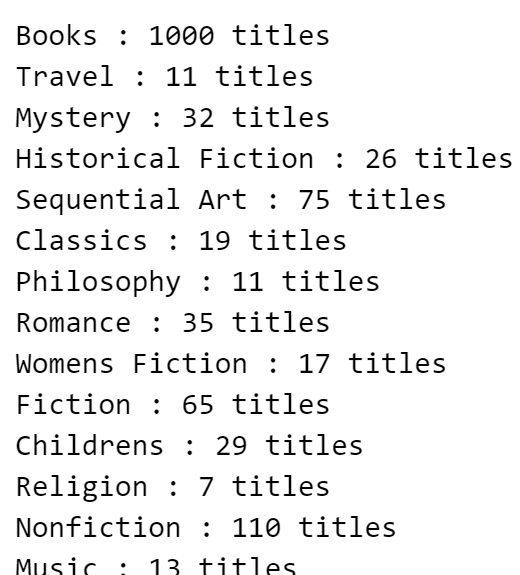

The number of titles can be found on the index page of each category. 

First scrape the category names and the corresponding index pages.  
Next scrape the number of titles from each index page.

In [9]:
side_categories = soup.find('div', class_='side_categories')
category_links = side_categories.find('ul').find('li').find('ul').find_all('a')
categories_data = []
base_url = 'http://books.toscrape.com/'
for link in category_links:
    name = link.text.strip()
    href = link['href']
    url = base_url + href
    resp = requests.get(url)
    cat_soup = BeautifulSoup(resp.text, 'html.parser')
    strong = cat_soup.select_one('form.form-horizontal strong')
    count = int(strong.text) if strong else 0
    categories_data.append((name, count))

print(categories_data)



[('Travel', 11), ('Mystery', 32), ('Historical Fiction', 26), ('Sequential Art', 75), ('Classics', 19), ('Philosophy', 11), ('Romance', 35), ('Womens Fiction', 17), ('Fiction', 65), ('Childrens', 29), ('Religion', 7), ('Nonfiction', 110), ('Music', 13), ('Default', 152), ('Science Fiction', 16), ('Sports and Games', 5), ('Add a comment', 67), ('Fantasy', 48), ('New Adult', 6), ('Young Adult', 54), ('Science', 14), ('Poetry', 19), ('Paranormal', 1), ('Art', 8), ('Psychology', 7), ('Autobiography', 9), ('Parenting', 1), ('Adult Fiction', 1), ('Humor', 10), ('Horror', 17), ('History', 18), ('Food and Drink', 30), ('Christian Fiction', 6), ('Business', 12), ('Biography', 5), ('Thriller', 11), ('Contemporary', 3), ('Spirituality', 6), ('Academic', 1), ('Self Help', 5), ('Historical', 2), ('Christian', 3), ('Suspense', 1), ('Short Stories', 1), ('Novels', 1), ('Health', 4), ('Politics', 3), ('Cultural', 1), ('Erotica', 1), ('Crime', 1)]
